In [ ]:
#Connect the Notebook to the Drive. So we can access Anywhere from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1) Import the core libraries for data handling
import pandas as pd   # pandas: for loading and manipulating tabular data (DataFrames)
import numpy as np    # numpy: for numerical operations, arrays, and handling NaN values

# 2) Load the kidney disease dataset from the provided CSV
df = pd.read_csv("/content/drive/MyDrive/kidney_disease.csv")

# 3) Check the overall shape: (number of rows, number of columns)
print("Shape:", df.shape)  # tells you how many samples (rows) and features (columns) there are

Shape: (400, 26)


In [ ]:
# 4) Look at the first 5 rows to get a feeling of the data
print(df.head())  # sample rows: shows feature values and the 'classification' column

   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]


In [ ]:
# 5) Printing a concise summary: column names, data types, non-null counts
print(df.info())  # helps us to see which columns are numeric, which are objects (strings), and where nulls appear

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:
# 6) Count missing values per column
print(df.isna().sum())#.sort_values(ascending="True"))  # shows how many NaNs each column has

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [ ]:
# 7) Look at the distribution of the target label
print(df["classification"].value_counts())  # shows how many 'ckd' and 'notckd' rows you have

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [ ]:
#Upto Here we observed and tried to know about our Dataset
#Now the process of cleaning Columns will be

In [ ]:
# 1) Drop the 'id' column since it is just a serial number, not a medical feature
if "id" in df.columns:
    df = df.drop(columns=["id"])  # removing non-informative identifier to avoid noise

In [ ]:
# 2) Replace textual placeholders for missing values with real NaN
df = df.replace("?", np.nan)     # turn "?" into np.nan so sklearn can recognize as missing
df = df.replace("\t?", np.nan)   # some cells use tab-embedded "?" -> also convert to NaN

In [ ]:
# 3) Standardize the 'classification' column (target)
df["classification"] = df["classification"].astype(str)        # ensure everything is treated as string
df["classification"] = df["classification"].str.strip()        # remove leading/trailing spaces and tabs
df["classification"] = df["classification"].str.lower()        # convert to lowercase: 'CKD' -> 'ckd'

In [ ]:
# 4) Fix any weird variants of 'ckd' such as 'ckd\t'
df["classification"] = df["classification"].replace({"ckd\t": "ckd"})

In [ ]:
# 5) Check the cleaned distribution of the target labels
print(df["classification"].value_counts())

classification
ckd       250
notckd    150
Name: count, dtype: int64


In [ ]:
#Upto Now I Cleaned the dataset.
#Now I have a features without any messy values and easy to go next processes


In [ ]:
# 1) Map textual classes to numbers: 'ckd' -> 1 (disease), 'notckd' -> 0 (no disease)
df["classification"] = df["classification"].map({"notckd": 0, "ckd": 1})

In [ ]:
# 2) Verifing no unexpected labels remain (should only see 0 and 1)
print(df["classification"].value_counts(dropna=False))

classification
1    250
0    150
Name: count, dtype: int64


In [ ]:
# 3) Define features matrix X and target vector y
X = df.drop(columns=["classification"])  # X contains all input features
y = df["classification"]                 # y contains the labels we want to predict

In [ ]:
#Now I have the Inputs to the models to train with data


In [ ]:
# 1) Let pandas figure out which columns are numeric types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# 2) All remaining columns (object types) are treated as categorical
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols,", No.Of Columns: ", len(numeric_cols))
print("Categorical columns:", categorical_cols,", No.Of Columns: ", len(categorical_cols))

Numeric columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo'] , No.Of Columns:  11
Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'] , No.Of Columns:  13


In [ ]:
#Why split:
#Numeric columns need imputation + scaling.
#Categorical columns need imputation + encoding (strings → numbers).

In [ ]:
from sklearn.impute import SimpleImputer             # to fill missing values
from sklearn.preprocessing import OneHotEncoder      # to encode categorical variables
from sklearn.preprocessing import StandardScaler     # to scale numeric variables
from sklearn.compose import ColumnTransformer        # to apply different transforms to different columns
from sklearn.pipeline import Pipeline                # to chain preprocessing and model together

# 1) Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # fill missing numeric entries using the median of each column
    ("scaler", StandardScaler())                    # scale numeric features to mean 0 and std 1 for better model performance
])

In [ ]:
# 2) Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing categories with the most common category
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     # convert categories to one-hot encoded columns, ignore new unseen categories
])

In [ ]:
# 3) Combine both preprocessors into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),  # apply numeric_transformer to numeric columns
        ("cat", categorical_transformer, categorical_cols)  # apply categorical_transformer to categorical columns
    ]
)

In [ ]:
#Now Iam going to split the dataset into traning and test sets

In [ ]:
from sklearn.model_selection import train_test_split  # for splitting into train and test sets

# 1) Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,                         # the full feature matrix
    y,                         # the target vector
    test_size=0.2,             # 20% of data for testing, 80% for training
    random_state=42,           # fixed seed to make results reproducible
    stratify=y                 # preserve the 0/1 class ratio in both train and test
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (320, 24) (320,)
Test shape : (80, 24) (80,)


In [ ]:
#Now Iam defining the all required models to be testing

In [ ]:
from sklearn.linear_model import LogisticRegression         # linear model, good baseline
from sklearn.ensemble import RandomForestClassifier         # tree ensemble
from sklearn.svm import SVC                                 # support vector classifier
from sklearn.neighbors import KNeighborsClassifier          # k-nearest neighbors
from sklearn.neural_network import MLPClassifier            # feedforward neural network
from xgboost import XGBClassifier                           # gradient boosting tree model

# 1) Define a dictionary of model name -> model instance
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),  # increased max_iter to ensure convergence
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),              # probability=True enables predict_proba for ROC-AUC
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"                                   # avoid warning; use logloss for binary classification
    )
}

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# 1) Prepare a list to store evaluation results for each model
results = []

# 2) Loop over each model
for name, model in models.items():
    print(f"\nTraining model: {name}")

    # 3) Build a full pipeline: preprocessing + model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),  # step 1: clean, impute, scale, encode the data
        ("model", model)                 # step 2: apply the chosen classifier
    ])

    # 4) Fit the pipeline on the training data
    clf.fit(X_train, y_train)           # during fit, preprocessor learns imputation/scaling, model learns patterns

    # 5) Make predictions on the test data
    y_pred = clf.predict(X_test)        # predicted class labels (0 or 1) for evaluation

    # 6) Predict probabilities for ROC-AUC if the model supports it
    if hasattr(clf.named_steps["model"], "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]  # probability of class 1 (ckd)
    else:
        y_proba = None

    # 7) Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)                              # fraction of correct predictions
    prec = precision_score(y_test, y_pred, zero_division=0)           # TP / (TP + FP)
    rec = recall_score(y_test, y_pred, zero_division=0)               # TP / (TP + FN)
    f1 = f1_score(y_test, y_pred, zero_division=0)                    # harmonic mean of precision and recall

    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba)                          # area under ROC curve using probabilities
    else:
        roc = np.nan                                                  # if no probabilities, can't compute ROC-AUC

    # 8) Store model name and scores
    results.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc
    })

# 9) Convert results to a DataFrame for easy viewing and sorting
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
print("\nModel comparison:")
print(results_df)


Training model: Logistic Regression

Training model: Random Forest

Training model: SVM

Training model: KNN

Training model: MLP

Training model: XGBoost

Model comparison:
                 model  accuracy  precision  recall        f1   roc_auc
0  Logistic Regression    1.0000        1.0    1.00  1.000000  1.000000
1        Random Forest    1.0000        1.0    1.00  1.000000  1.000000
2                  SVM    1.0000        1.0    1.00  1.000000  1.000000
4                  MLP    0.9875        1.0    0.98  0.989899  1.000000
5              XGBoost    0.9875        1.0    0.98  0.989899  1.000000
3                  KNN    0.9750        1.0    0.96  0.979592  0.999333


Best model by F1: Logistic Regression


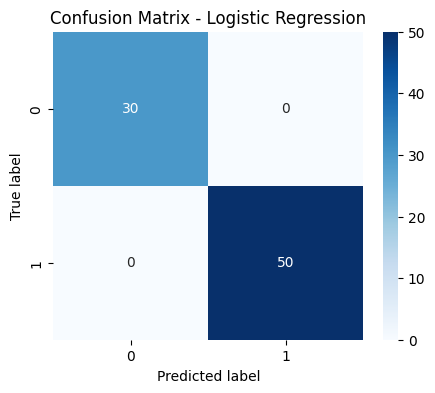

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1) Identify best model by F1-score
best_model_name = results_df.iloc[0]["model"]
print("Best model by F1:", best_model_name)

best_model = models[best_model_name]

# 2) Rebuild the pipeline for the best model
best_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

# 3) Fit on training data
best_clf.fit(X_train, y_train)

# 4) Predict on test data
y_pred = best_clf.predict(X_test)

# 5) Confusion matrix: counts of TP, TN, FP, FN
cm = confusion_matrix(y_test, y_pred)

# 6) Visualize confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")      # x-axis: model predictions
plt.ylabel("True label")           # y-axis: actual labels
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# 7) Detailed metrics per class (precision, recall, F1)
print(classification_report(y_test, y_pred, zero_division=0))

In [ ]:
import joblib

joblib.dump(best_clf, "ckd_logreg_pipeline.pkl")

['ckd_logreg_pipeline.pkl']